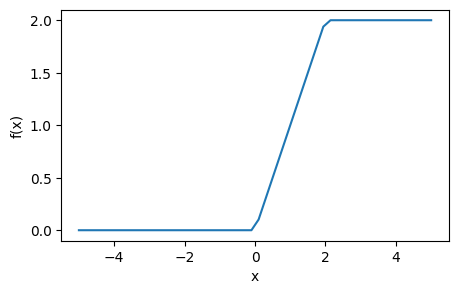

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    return np.maximum(z, 0)

def plot_func(f, xmin, xmax, **kwargs):
    x_grid = np.linspace(xmin, xmax)
    y_grid = [f(x) for x in x_grid]
    plt.plot(x_grid, y_grid, **kwargs)

class SimpleNN:
    def __init__(self, w, b, a):
        self.w = np.array(w)
        self.b = np.array(b)
        self.a = np.array(a)

    def forward(self, x):
        out = 0
        for i in range(len(self.w)):
            wi, bi, ai = self.w[i], self.b[i], self.a[i]
            out += ai * relu(wi * x + bi)
        return out

# Example use
w = [1, 1]
b = [0, -2]
a = [1, -1]

model = SimpleNN(w, b, a)

plt.figure(figsize=(5, 3))
plot_func(model.forward, -5, 5)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


Text(25.22222222222222, 0.5, 'y (labels)')

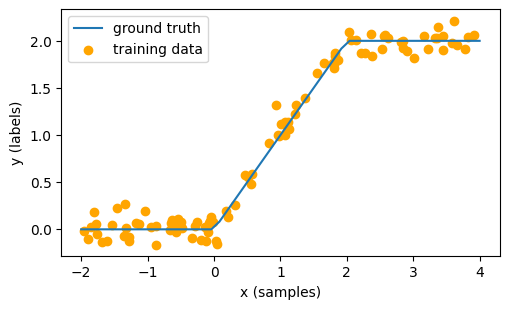

In [42]:
w = [1, 1]
b = [0, -2]
a = [1, -1]

model_gt = SimpleNN(w, b, a)

x = np.random.uniform(-2,4, 100)
y = model_gt.forward(x) + 0.1*np.random.randn(100)
plt.figure(figsize=(5,3))
plot_func(model.forward, -2, 4, label='ground truth')
plt.scatter(x,y, color = 'orange', label='training data')
plt.legend()
plt.tight_layout()
plt.xlabel('x (samples)')
plt.ylabel('y (labels)')

Text(13.722222222222223, 0.5, 'y (labels)')

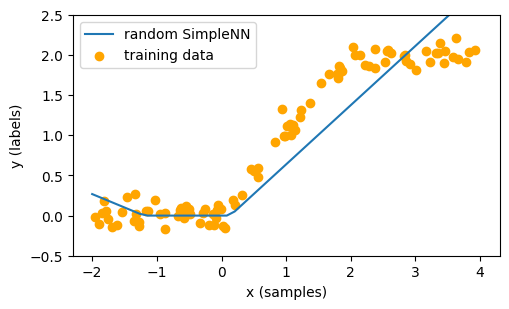

In [43]:
# Example use
w = np.random.randn(2)
b = np.random.randn(2)
a = np.random.randn(2)

model_random = SimpleNN(w, b, a)

plt.figure(figsize=(5,3))
plot_func(model_random.forward, -2, 4, label='random SimpleNN')
plt.scatter(x,y, color = 'orange', label='training data')
plt.ylim([-0.5,2.5])
plt.legend()
plt.tight_layout()
plt.xlabel('x (samples)')
plt.ylabel('y (labels)')


In [44]:
w = [1, 1]
b = [0, -2]
a = [1, -1]

model = SimpleNN(w, b, a)

x = np.random.uniform(-2,4, 100)
y = model.forward(x) + 0.1*np.random.randn(100)

# SUPPOSE we didn't know the above parameters
np.random.seed(42)
init_scale = 1.0
w = init_scale*np.random.randn(2)
b = init_scale*np.random.randn(2)
a = init_scale*np.random.randn(2)

model = SimpleNN(w, b, a)

lr = 0.002

num_steps = 1000

relu_deriv = lambda z : 1 if z > 0.0 else 0.0

for step in range(num_steps):
    grad_w = np.zeros_like(model.w)
    grad_b = np.zeros_like(model.b)
    grad_a = np.zeros_like(model.a)
    loss = 0.0

    for xi, yi in zip(x, y):
        yhati = model.forward(xi)
        coef = -2*(yi - yhati)

        for j in range(len(model.w)):
            zij = model.w[j] * xi + model.b[j]
            hij = relu(zij)
            
            grad_a[j] += coef * hij
            grad_w[j] += coef * model.a[j] * relu_deriv(zij) * xi
            grad_b[j] += coef * model.a[j] * relu_deriv(zij)

        # END OF for j in range(len(model.w)):
        loss += (yi - yhati)**2

    m = len(x)
    grad_w /= m
    grad_b /= m
    grad_a /= m
    loss /= m

    # gradient step
    model.w -= lr * grad_w
    model.b -= lr * grad_b
    model.a -= lr * grad_a


Text(13.722222222222223, 0.5, 'y (labels)')

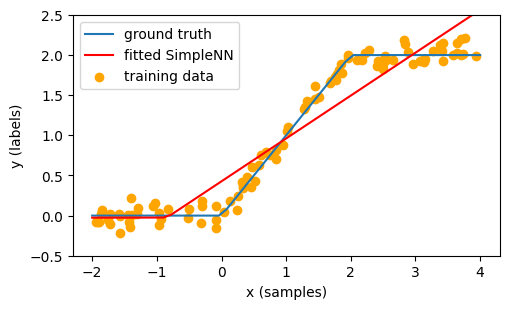

In [45]:

plt.figure(figsize=(5,3))
plot_func(model_gt.forward, -2, 4, label='ground truth')
plot_func(model.forward, -2, 4,  color='red',label='fitted SimpleNN')

plt.scatter(x,y, color = 'orange', label='training data')
plt.ylim([-0.5,2.5])
plt.legend()
plt.tight_layout()
plt.xlabel('x (samples)')
plt.ylabel('y (labels)')

In [ ]:
w = [1, 1]
b = [0, -2]
a = [1, -1]

model = SimpleNN(w, b, a)

# >>> teacher network
# use 2-neuron net to generate the data
x = np.random.uniform(-2,4, 100)
y = model.forward(x) + 0.1*np.random.randn(100)

# >>> student network

np.random.seed(42)
init_scale = 1.0
num_neurons = 20
w = init_scale*np.random.randn(num_neurons)
b = init_scale*np.random.randn(num_neurons)
a = init_scale*np.random.randn(num_neurons)

model = SimpleNN(w, b, a)

lr = 0.01

num_steps = 1000

relu_deriv = lambda z : 1 if z > 0.0 else 0.0  # subgradient at 0 ignored for simplicity

for step in range(num_steps):
    grad_w = np.zeros_like(model.w)
    grad_b = np.zeros_like(model.b)
    grad_a = np.zeros_like(model.a)
    loss = 0.0

    for xi, yi in zip(x, y):
        yhati = model.forward(xi)
        coef = -2*(yi - yhati)

        for j in range(len(model.w)):
            zj = model.w[j] * xi + model.b[j]
            hj = relu(zj)
            relu_prime = relu_deriv(zj)

            grad_a[j] += coef * hj

            grad_w[j] += coef * model.a[j] * relu_prime * xi

            grad_b[j] += coef * model.a[j] * relu_prime

        loss += (yi - yhati)**2

    m = len(x)
    grad_w /= m
    grad_b /= m
    grad_a /= m
    loss /= m

    # gradient step
    model.w -= lr * grad_w
    model.b -= lr * grad_b
    model.a -= lr * grad_a


Text(13.722222222222223, 0.5, 'y (labels)')

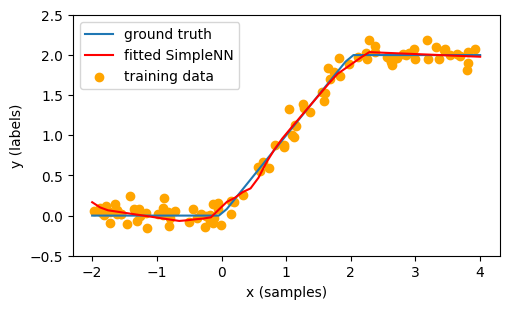

In [47]:

plt.figure(figsize=(5,3))
plot_func(model_gt.forward, -2, 4, label='ground truth')
plot_func(model.forward, -2, 4, color='red',label='fitted SimpleNN')

plt.scatter(x,y, color = 'orange', label='training data')
plt.ylim([-0.5,2.5])
plt.legend()
plt.tight_layout()
plt.xlabel('x (samples)')
plt.ylabel('y (labels)')
